# LHCb $D_s^+\to\pi^-\pi^+\pi^+$ — real-data fit with a per-event signal probability

This is a copy of `ds_pipipi_lhcb2023_goofit_real_data_fit_cow_bkghist.ipynb` that replaces the
single, fixed signal fraction of the Dalitz likelihood by a **per-event signal probability**
computed from the reconstructed $D_s^+$ mass (`D_MM`).

The fit runs in two steps:

1. **External mass fit.** The full `D_MM` spectrum is fitted on its own with an extended unbinned
   likelihood (Chapter 4 of LHCb-ANA-2022-011: Crystal Ball + Gaussian signal, exponential
   combinatorial background), exactly as in the sibling notebooks. With the mass parameters frozen,
   every candidate gets

   $$p_i=\frac{N_s\,P_s(m_i)}{N_s\,P_s(m_i)+N_b\,P_b(m_i)}.$$

2. **Dalitz fit.** The amplitude model is fitted with

   $$-\ln\mathcal{L}=-\sum_i\ln\big[p_i\,S(x_i)+(1-p_i)\,B(x_i)\big],$$

   where $S$ is the normalized, efficiency-corrected signal Dalitz density and $B$ is the
   COW-derived background histogram. A candidate in the peak enters as almost pure signal and a
   candidate in the mass tails as almost pure background, whereas the fixed-fraction fit gives every
   candidate in the mass window the same prior signal probability $N_s/(N_s+N_b)$.

**Relation to a simultaneous (mass, Dalitz) fit.** If the mass and Dalitz coordinates factorize
within each category, the joint density is

$$N_s P_s(m)S(x)+N_b P_b(m)B(x)=\big[N_s P_s(m)+N_b P_b(m)\big]\,\big[p(m)\,S(x)+(1-p(m))\,B(x)\big].$$

The first factor does not depend on any Dalitz parameter, so this two-step fit gives exactly the
Dalitz result of the simultaneous fit with the mass-shape parameters and yields fixed at their
mass-fit values. Two caveats follow:

- the factorization must hold: the Dalitz invariants are the DTF (mass-constrained) `*_DTF`
  branches, while `D_MM` is the unconstrained mass, and the background Dalitz distribution is
  assumed not to change across the mass range;
- the statistical uncertainty of the mass fit is not propagated into the Dalitz errors. It is a
  systematic, which can be estimated by refitting with mass parameters drawn from the mass-fit
  covariance.

The particle ordering is $(\pi^-,\pi^+,\pi^+)$: `s12` and `s13` are the two opposite-sign
$\pi^-\pi^+$ combinations and `s23` is the same-sign $\pi^+\pi^+$ combination.

Reference amplitude model: LHCb, JHEP 07 (2023) 204, arXiv:2209.09840.

In [1]:
import gc
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from sweights import Cow

from jaxpwa import (
    BackgroundSpec,
    CrystalBall1D,
    DecayChannel,
    DecayModel,
    Exponential1D,
    FitSession,
    Gaussian1D,
    GounarisSakurai,
    GooFitLegacyAngular,
    Minimizer,
    Parameter,
    PhaseSpaceSample,
    QMI,
    RealImag,
    Resonance,
    ToyBackground,
    dalitz_s13_limits,
    enable_x64,
    generate_toy,
    histogram_efficiency_from_root,
    read_root_tree,
)
# `HistogramBackground` is a low-level building block (docs/backgrounds_and_vetoes.md); it is
# not re-exported at the jaxpwa top level, unlike its ROOT-file loader
# `histogram_background_from_root`, since here the histogram is built from arrays instead.
from jaxpwa.background import HistogramBackground

enable_x64()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]


## 1. Input files, mass branch and Dalitz convention

Install the optional sPlot/COW dependency with `python -m pip install -e ".[splot]"`; the package already declares `splot = ["sweights"]` in `pyproject.toml`.

The ROOT branches are read in one call so the mass values and Dalitz coordinates stay event-by-event aligned. `MASS_TO_GEV` is explicit rather than inferred: keep `1e-3` for a mass branch stored in MeV and change it to `1.0` if the branch is already in GeV.


In [2]:
DATA_FILE = Path('/Users/juanleite/Work/data/DsPPP_FullData_AllSelectionCuts_Splot_FReweighted_MeanMVA.root')
DATA_TREE = 'DecayTree'

S12_BRANCH = 's12_pipi_DTF'
S13_BRANCH = 's13_pipi_DTF'
S23_BRANCH = 's23_pipi_DTF'
MASS_BRANCH = 'D_MM'  # change to the mass branch in the full-spectrum sample
BDTG_BRANCH = 'valBDT_mean'
BDTG_MIN = 0.65

MASS_TO_GEV = 1e-3    # use 1.0 if MASS_BRANCH is already in GeV

# Chapter 4 / original sPlot fit range: 1910--2030 MeV.
MASS_RANGE_GEV = (1.910, 2.030)

DATA_CUT = None
ENTRY_START, ENTRY_STOP = None, None

EFFICIENCY_FILE = Path('/Users/juanleite/Work/data/acc_hist_15_95_Smoothed_normalized.root')
EFFICIENCY_HIST = 'h_eff'

RUN_PREFIT_TOY_COMPARISON = True
TOY_SEED = 20230922
RUN_FIT = True
RANDOMIZE_START = True  # start the fit from a random point instead of published_start
RANDOMIZE_SEED = None    # seed for RANDOMIZE_START; None draws a fresh point each run
RUN_FIXED_FRACTION_COMPARISON = False  # also run the fixed-fraction fit (doubles the run time)

## 2. Published QMI S-wave starting point

The 50 knots below are the central values used as the fit starting point. `QMI(..., interpolation='linear')` linearly interpolates the magnitude and phase parameters in $s=m^2$.

In [3]:
QMI_KNOTS_GEV = np.array([
    0.280,0.390,0.470,0.546,0.623,0.698,0.766,0.819,0.865,0.900,
    0.925,0.942,0.955,0.964,0.972,0.978,0.983,0.990,1.001,1.023,
    1.051,1.083,1.116,1.149,1.179,1.205,1.227,1.245,1.261,1.276,
    1.289,1.302,1.314,1.326,1.338,1.351,1.363,1.375,1.387,1.399,
    1.411,1.424,1.437,1.450,1.465,1.484,1.511,1.554,1.613,1.823,
])
QMI_MAGNITUDE_PAPER = np.array([
    4.54,4.05,4.10,4.41,4.69,4.691,4.994,5.43,6.405,8.096,
    10.624,13.47,16.56,19.45,22.15,24.62,26.95,20.89,13.695,10.995,
    9.593,8.731,7.606,6.961,6.515,6.506,6.264,6.125,6.081,6.071,
    5.912,5.893,5.901,6.031,5.904,6.086,6.181,6.185,6.60,6.63,
    6.90,7.14,7.22,7.56,7.33,7.13,5.009,2.456,2.31,3.75,
])
QMI_PHASE_DEG_PAPER = np.array([
    176.8,152.8,147.6,146.4,149.6,157.4,169.5,-172.8,-152.0,-133.0,
    -116.5,-103.0,-88.8,-74.9,-59.5,-56.7,-21.8,-9.8,5.45,11.28,
    21.57,36.27,48.02,54.42,63.46,63.47,72.45,72.80,77.2,82.2,
    86.1,88.8,93.2,93.8,98.7,103.3,105.7,110.4,114.5,119.7,
    126.5,132.3,142.03,153.74,166.50,-172.15,-136.8,-126.8,-99.5,3.0,
])
QMI_PHASE_RAD_START = np.unwrap(np.deg2rad(QMI_PHASE_DEG_PAPER))
assert len(QMI_KNOTS_GEV) == len(QMI_MAGNITUDE_PAPER) == len(QMI_PHASE_RAD_START) == 50

## 3. Build the amplitude model

The $f_2(1270)$ coefficient is the fixed reference. The QMI contributes 100 floating dynamics parameters and the five other resonances contribute five complex coefficients, for 110 free parameters.

In [4]:
def polar_coefficient(name, magnitude, phase_deg, *, fixed=False):
    phase = np.deg2rad(phase_deg)
    x = float(magnitude * np.cos(phase))
    y = float(magnitude * np.sin(phase))
    if fixed:
        return RealImag(x, y)
    return RealImag(
        Parameter.coefficient(f'{name}.x', x, owner=name, step=0.01),
        Parameter.coefficient(f'{name}.y', y, owner=name, step=0.01),
    )

S_OWNER = 'pipi_S_qmi'
s_magnitudes = tuple(
    Parameter.dynamics(f'S.mag_{i:02d}', float(v), owner=S_OWNER, bounds=(0.0, None), step=max(0.02, 0.01*float(v)))
    for i, v in enumerate(QMI_MAGNITUDE_PAPER)
)
s_phases = tuple(
    Parameter.dynamics(f'S.phase_{i:02d}', float(v), owner=S_OWNER, step=np.deg2rad(1.0))
    for i, v in enumerate(QMI_PHASE_RAD_START)
)
qmi_s_wave = QMI(tuple(QMI_KNOTS_GEV), s_magnitudes, s_phases, interpolation='linear')

coeff = {
    'rho770': polar_coefficient('rho770', 0.1201, 79.4),
    'omega782': polar_coefficient('omega782', 0.04001, -109.9),
    'rho1450': polar_coefficient('rho1450', 1.277, -115.2),
    'rho1700': polar_coefficient('rho1700', 0.873, -60.9),
    'f2_1270': polar_coefficient('f2_1270', 1.0, 0.0, fixed=True),
    'f2p_1525': polar_coefficient('f2p_1525', 0.1098, 178.1),
}

channel = DecayChannel('D_s+', ('pi-', 'pi+', 'pi+'))
angular = GooFitLegacyAngular()
bachelor_momentum_frame="parent"
R_D, R_R = 5.0, 1.5

def resonance(name, coefficient, mass, width, spin, *, lineshape=None):
    kwargs = {} if lineshape is None else {'lineshape': lineshape}
    return Resonance(
        name, (0, 1), coefficient, mass=mass, width=width, spin=spin,
        angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame, **kwargs
    )

model = DecayModel(
    channel,
    [
        Resonance(S_OWNER, (0, 1), RealImag(1.0, 0.0), mass=1.0, width=0.0, spin=0,
                  lineshape=qmi_s_wave, angular=angular, resonance_radius=R_R, parent_radius=R_D, bachelor_momentum_frame=bachelor_momentum_frame),
        resonance('rho770', coeff['rho770'], 0.77526, 0.1491, 1, lineshape=GounarisSakurai()),
        resonance('omega782', coeff['omega782'], 0.78265, 0.00849, 1),
        resonance('rho1450', coeff['rho1450'], 1.465, 0.400, 1),
        resonance('rho1700', coeff['rho1700'], 1.720, 0.250, 1),
        resonance('f2_1270', coeff['f2_1270'], 1.2755, 0.1867, 2),
        resonance('f2p_1525', coeff['f2p_1525'], 1.5174, 0.086, 2),
    ],
    normalize_components=False,
)

print('components:', [c.name for c in model.components])
print('free model parameters:', sum(not p.fixed for p in model.parameters))
assert sum(not p.fixed for p in model.parameters) == 110

components: ['pipi_S_qmi', 'rho770', 'omega782', 'rho1450', 'rho1700', 'f2_1270', 'f2p_1525']
free model parameters: 110


## 4. Read data, apply the final BDT cut, and require physical Dalitz support

The final MVA requirement, `valBDT_mean > 0.65`, is applied immediately after loading the ROOT tree. The 1910--2030 MeV mass range is then selected, followed by the exact physical $D_s^+\to\pi^-\pi^+\pi^+$ Dalitz support requirement.

This ordering is deliberate: **the extended mass fit, its signal/background yields, the COW construction, the background histogram, and the amplitude fit all use exactly the same event sample**.

Before the physical-support cut, the stored DTF invariants are checked against

$$
s_{12}+s_{13}+s_{23}
=
m_{D_s}^2+m_1^2+m_2^2+m_3^2.
$$

The physical-domain test uses $s_{12}$ and the exact allowed $s_{13}$ interval at fixed $s_{12}$. For accepted events, $s_{23}$ is reconstructed from the closure relation so the amplitude model receives an exactly self-consistent invariant triplet.

No sideband ROOT background histogram is loaded here. Instead, Section 8 below builds the
`(s12, s13)` background histogram directly from this same sample's COW background weights.


In [5]:
arrays = read_root_tree(
    DATA_FILE,
    DATA_TREE,
    {
        's12': S12_BRANCH,
        's13': S13_BRANCH,
        's23': S23_BRANCH,
        'mass': MASS_BRANCH,
        'bdtg': BDTG_BRANCH,
    },
    cut=DATA_CUT,
    entry_start=ENTRY_START,
    entry_stop=ENTRY_STOP,
    library='np',
)

mass_all = np.asarray(arrays['mass'], dtype=float) * MASS_TO_GEV
bdtg_all = np.asarray(arrays['bdtg'], dtype=float)
s12_all = np.asarray(arrays['s12'], dtype=float)
s13_all = np.asarray(arrays['s13'], dtype=float)
s23_all = np.asarray(arrays['s23'], dtype=float)

bdtg_mask = np.isfinite(bdtg_all) & (bdtg_all > BDTG_MIN)
mass_range_mask = (
    bdtg_mask
    & np.isfinite(mass_all)
    & (mass_all >= MASS_RANGE_GEV[0])
    & (mass_all <= MASS_RANGE_GEV[1])
)

# Inspect the stored DTF invariant closure before applying the physical-Dalitz cut.
M = float(channel.parent_mass)
m1, m2, m3 = map(float, channel.daughter_masses)
dalitz_constant = M**2 + m1**2 + m2**2 + m3**2

candidate_indices = np.flatnonzero(mass_range_mask)
s12_candidate = s12_all[candidate_indices]
s13_candidate = s13_all[candidate_indices]
s23_candidate = s23_all[candidate_indices]

closure = s12_candidate + s13_candidate + s23_candidate - dalitz_constant
finite_closure = np.isfinite(closure)
abs_closure = np.abs(closure[finite_closure])

print('DTF closure diagnostic before physical-Dalitz selection:')
if abs_closure.size:
    print(f'  median(closure)       = {np.median(closure[finite_closure]): .6e} GeV^2')
    print(f'  RMS(closure)          = {np.sqrt(np.mean(closure[finite_closure]**2)): .6e} GeV^2')
    print(f'  99.9% |closure|       = {np.quantile(abs_closure, 0.999): .6e} GeV^2')
    print(f'  max |closure|         = {abs_closure.max(): .6e} GeV^2')
else:
    print('  no finite closure values')

s12_min = (m1 + m2)**2
s12_max = (M - m3)**2

s13_low_jax, s13_high_jax = dalitz_s13_limits(
    jnp.asarray(s12_candidate),
    mother_mass=M,
    masses=(m1, m2, m3),
)
s13_low = np.asarray(s13_low_jax)
s13_high = np.asarray(s13_high_jax)

finite_dalitz = (
    np.isfinite(s12_candidate)
    & np.isfinite(s13_candidate)
    & np.isfinite(s23_candidate)
)
physical_s12 = (s12_candidate >= s12_min) & (s12_candidate <= s12_max)
physical_s13 = (s13_candidate >= s13_low) & (s13_candidate <= s13_high)

s23_reconstructed_candidate = dalitz_constant - s12_candidate - s13_candidate
s23_min = (m2 + m3)**2
s23_max = (M - m1)**2
physical_s23 = (
    np.isfinite(s23_reconstructed_candidate)
    & (s23_reconstructed_candidate >= s23_min)
    & (s23_reconstructed_candidate <= s23_max)
)

physical_candidate_mask = (
    finite_dalitz
    & physical_s12
    & physical_s13
    & physical_s23
)

selected_indices = candidate_indices[physical_candidate_mask]
n_mass_range = candidate_indices.size
n_physical = selected_indices.size
n_rejected = n_mass_range - n_physical

mass = mass_all[selected_indices]
s12 = s12_all[selected_indices]
s13 = s13_all[selected_indices]
s23 = dalitz_constant - s12 - s13

data = PhaseSpaceSample(
    s12=jnp.asarray(s12),
    s13=jnp.asarray(s13),
    s23=jnp.asarray(s23),
    weights=jnp.ones(n_physical, dtype=jnp.float64),
)

efficiency = histogram_efficiency_from_root(
    EFFICIENCY_FILE,
    EFFICIENCY_HIST,
    x_variable='s12',
    y_variable='s13',
)

print()
print(f'Loaded {len(mass_all):,} candidates')
print(
    f'After {BDTG_BRANCH} > {BDTG_MIN}: '
    f'{np.count_nonzero(bdtg_mask):,} candidates'
)
print(
    f'After BDT + {MASS_RANGE_GEV[0]:.3f} < m < {MASS_RANGE_GEV[1]:.3f} GeV: '
    f'{n_mass_range:,} candidates'
)
print(
    f'Inside physical Dalitz support: {n_physical:,} candidates'
)
print(
    f'Rejected as non-physical: {n_rejected:,} '
    f'({100.0*n_rejected/max(n_mass_range, 1):.4f}%)'
)
print(f'  outside global s12     = {np.count_nonzero(~physical_s12):,}')
print(f'  outside s13(s12) band  = {np.count_nonzero(physical_s12 & ~physical_s13):,}')
print(f'  outside reconstructed s23 range = {np.count_nonzero(~physical_s23):,}')

bad_candidate_indices = np.flatnonzero(~physical_candidate_mask)
if bad_candidate_indices.size:
    print()
    print('First rejected candidates:')
    for local_idx in bad_candidate_indices[:10]:
        original_idx = candidate_indices[local_idx]
        print(
            f'  i={original_idx:7d}  m={mass_all[original_idx]:.6f}  '
            f's12={s12_candidate[local_idx]:.6f}  '
            f's13={s13_candidate[local_idx]:.6f}  '
            f's23(stored)={s23_candidate[local_idx]:.6f}  '
            f'closure={closure[local_idx]:+.3e}'
        )

selected_closure = (
    np.asarray(data.s12)
    + np.asarray(data.s13)
    + np.asarray(data.s23)
    - dalitz_constant
)
print(f'max reconstructed |closure| = {np.max(np.abs(selected_closure)):.3e} GeV^2')

for name in ('s12', 's13', 's23'):
    values = np.asarray(getattr(data, name))
    print(f'{name}: [{values.min():.6g}, {values.max():.6g}] GeV^2')


DTF closure diagnostic before physical-Dalitz selection:
  median(closure)       =  5.509823e-04 GeV^2
  RMS(closure)          =  6.832844e-03 GeV^2
  99.9% |closure|       =  6.442568e-02 GeV^2
  max |closure|         =  1.053484e+00 GeV^2

Loaded 8,907,420 candidates
After valBDT_mean > 0.65: 900,268 candidates
After BDT + 1.910 < m < 2.030 GeV: 900,268 candidates
Inside physical Dalitz support: 899,831 candidates
Rejected as non-physical: 437 (0.0485%)
  outside global s12     = 0
  outside s13(s12) band  = 437
  outside reconstructed s23 range = 109

First rejected candidates:
  i=  25325  m=1.962576  s12=2.365538  s13=1.485258  s23(stored)=0.082597  closure=+5.510e-04
  i=  49293  m=1.978248  s12=0.971924  s13=2.856676  s23(stored)=0.104792  closure=+5.510e-04
  i= 123821  m=1.956467  s12=1.900937  s13=1.954519  s23(stored)=0.077936  closure=+5.510e-04
  i= 133820  m=1.960861  s12=2.892030  s13=0.933907  s23(stored)=0.107456  closure=+5.510e-04
  i= 214750  m=1.973898  s12=1.85159

### Raw $D_s^+\to\pi^-\pi^+\pi^+$ mass spectrum before the fit

Sanity check on the **same sample that will be used throughout the rest of the notebook**: `valBDT_mean > 0.65`, 1910--2030 MeV, and inside the physical $D_s$ Dalitz support.


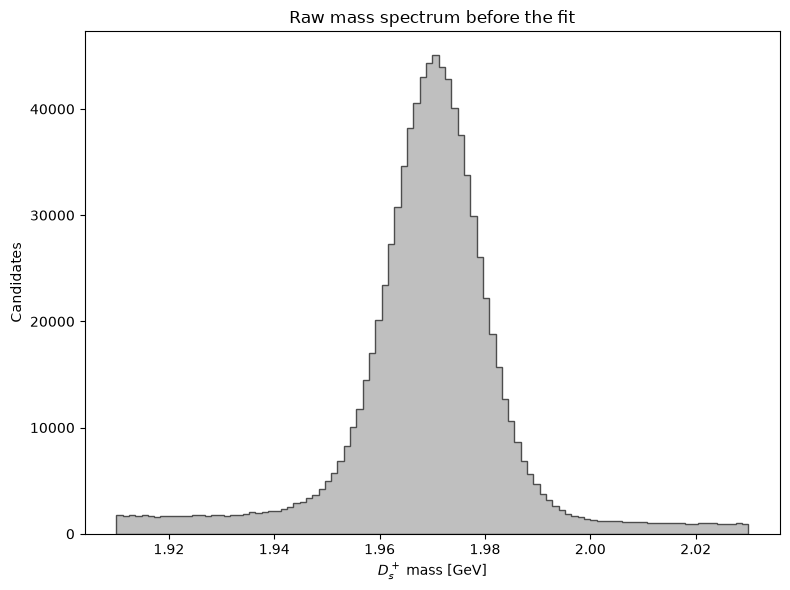

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(mass, bins=100, range=MASS_RANGE_GEV, histtype='stepfilled', color='0.75', edgecolor='0.3')
ax.set_xlabel(r'$D_s^+$ mass [GeV]')
ax.set_ylabel('Candidates')
ax.set_title('Raw mass spectrum before the fit')
fig.tight_layout()
plt.show()

## 5. Extended mass fit — Chapter 4 model

The mass fit follows the analysis-note parameterisation:

$$
P_s(m)=f_{CB}\,CB(m;\alpha,n,\mu_{CB},\sigma_{CB})
+(1-f_{CB})\,G(m;\mu_G,\sigma_G),
$$

with

$$
\mu_G=\mu_{CB}+\mu_{\mathrm{offset}},
\qquad
\sigma_G=\sigma_{CB}\,\sigma_{\mathrm{Ratio}},
$$

and an exponential background. All signal-shape parameters, the exponential slope, and the two extended yields are free. The numerical starting values below reproduce the central values from Table 11 where available; the background slope is only a numerical seed because it is not quoted in that table.

Following `ds_pipipi_lhcb2023_goofit_real_data_fit_cow_sweights_logbarrier.ipynb`, the mass PDFs
use Jax-PWA's own 1D discriminant PDFs (`CrystalBall1D`, `Gaussian1D`, `Exponential1D`,
`jaxpwa.discriminants`) fitted through Jax-PWA's own `Minimizer`, instead of
`iminuit.cost.ExtendedUnbinnedNLL` over `scipy.stats.crystalball`. The whole mass density is then
JAX end to end, so `Minimizer` gets exact `jax.grad` gradients and JIT-compiles one
value-and-gradient program, rather than Minuit finite-differencing 10 parameters through a
pure-Python/scipy PDF on ~900k events per call.


In [7]:
MASS_LOW, MASS_HIGH = MASS_RANGE_GEV


def signal_mass_pdf(x, alpha, n, mu_cb, sigma_cb, mu_offset, sigma_ratio, f_cb):
    mu_g = mu_cb + mu_offset
    sigma_g = sigma_cb * sigma_ratio
    cb = CrystalBall1D(
        mean=mu_cb, sigma=sigma_cb, alpha=alpha, n=n, low=MASS_LOW, high=MASS_HIGH
    )
    gauss = Gaussian1D(mean=mu_g, sigma=sigma_g, low=MASS_LOW, high=MASS_HIGH)
    return f_cb * cb(x) + (1.0 - f_cb) * gauss(x)


def background_mass_pdf(x, slope):
    return Exponential1D(slope=slope, low=MASS_LOW, high=MASS_HIGH)(x)


mass_jax = jnp.asarray(mass)


def mass_nll(parameters):
    nsig = parameters['nsig']
    nbkg = parameters['nbkg']
    signal = signal_mass_pdf(
        mass_jax,
        parameters['alpha'],
        parameters['n'],
        parameters['mu_cb'],
        parameters['sigma_cb'],
        parameters['mu_offset'],
        parameters['sigma_ratio'],
        parameters['f_cb'],
    )
    background = background_mass_pdf(mass_jax, parameters['slope'])
    density = nsig * signal + nbkg * background
    return (nsig + nbkg) - jnp.sum(jnp.log(density))


# Table 11 central values, converted from MeV to GeV where appropriate.
mass_parameters_config = [
    Parameter('nsig', 771_130.0, bounds=(0.0, None)),
    Parameter('nbkg', 129_288.0, bounds=(0.0, None)),
    Parameter('alpha', 1.681, bounds=(0.05, 10.0)),
    Parameter('n', 11.0, bounds=(1.01, 100.0)),
    Parameter('mu_cb', 1.96978, bounds=MASS_RANGE_GEV),
    Parameter('sigma_cb', 0.01039, bounds=(5e-4, 0.05)),
    Parameter('mu_offset', 0.00098, bounds=(-0.02, 0.02)),
    Parameter('sigma_ratio', 0.6666, bounds=(0.05, 5.0)),
    Parameter('f_cb', 0.52, bounds=(0.0, 1.0)),
    Parameter('slope', -5.0, bounds=(-100.0, 100.0)),
]

mass_minimizer = Minimizer(mass_nll, mass_parameters_config)
mass_fit = mass_minimizer.fit()
print(mass_fit)

# Only the fitted `mass_fit` result is needed downstream: drop the
# JIT-compiled objective and the device array it closes over.
del mass_nll, mass_jax, mass_minimizer
gc.collect()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = -1.406e+07                 │        Nfcn = 659, Ngrad = 8         │
│ EDM = 3.8e-08 (Goal: 1e-07)      │            time = 8.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────

3416

mu_G       = 1970.741 MeV
sigma_G    = 6.978 MeV
sigma_eff  = 8.927 MeV
legacy signal region (mu_CB +/- 2 sigma_eff): [1951.9, 1987.6] MeV


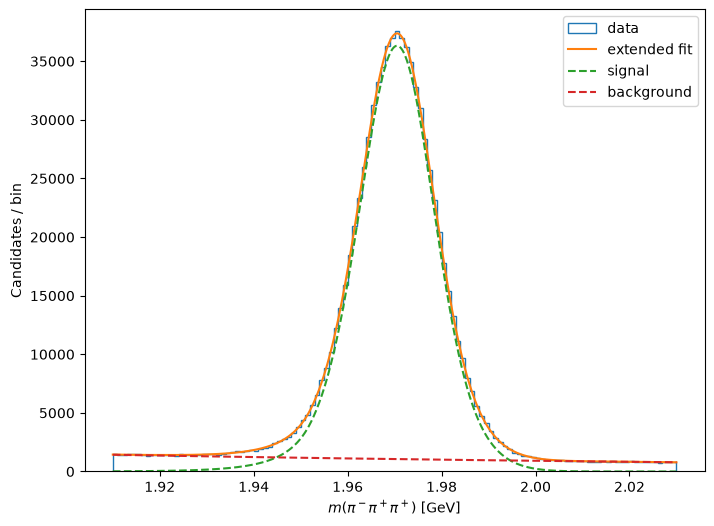

In [8]:
mass_parameters = mass_fit.values.to_dict()

mu_g_fit = mass_parameters['mu_cb'] + mass_parameters['mu_offset']
sigma_g_fit = mass_parameters['sigma_cb'] * mass_parameters['sigma_ratio']
sigma_eff_fit = np.sqrt(
    mass_parameters['f_cb'] * mass_parameters['sigma_cb']**2
    + (1.0 - mass_parameters['f_cb']) * sigma_g_fit**2
)

print(f'mu_G       = {1e3 * mu_g_fit:.3f} MeV')
print(f'sigma_G    = {1e3 * sigma_g_fit:.3f} MeV')
print(f'sigma_eff  = {1e3 * sigma_eff_fit:.3f} MeV')
print(
    'legacy signal region (mu_CB +/- 2 sigma_eff): '
    f'[{1e3 * (mass_parameters["mu_cb"] - 2 * sigma_eff_fit):.1f}, '
    f'{1e3 * (mass_parameters["mu_cb"] + 2 * sigma_eff_fit):.1f}] MeV'
)

x_mass = np.linspace(MASS_LOW, MASS_HIGH, 1000)
signal_curve = signal_mass_pdf(
    x_mass,
    mass_parameters['alpha'],
    mass_parameters['n'],
    mass_parameters['mu_cb'],
    mass_parameters['sigma_cb'],
    mass_parameters['mu_offset'],
    mass_parameters['sigma_ratio'],
    mass_parameters['f_cb'],
)
background_curve = background_mass_pdf(x_mass, mass_parameters['slope'])

fig, ax = plt.subplots(figsize=(8, 6))
counts, edges, _ = ax.hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    histtype='step',
    label='data',
)
bin_width = edges[1] - edges[0]
ax.plot(
    x_mass,
    bin_width * (
        mass_parameters['nsig'] * signal_curve
        + mass_parameters['nbkg'] * background_curve
    ),
    label='extended fit',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nsig'] * signal_curve,
    '--',
    label='signal',
)
ax.plot(
    x_mass,
    bin_width * mass_parameters['nbkg'] * background_curve,
    '--',
    label='background',
)
ax.set(xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]', ylabel='Candidates / bin')
ax.legend()
plt.show()


## 6. COW signal weights

The fitted signal and background shapes are frozen and passed to `sweights.Cow`. The extended mass fit above was performed **after** the BDT, mass-range, and physical-Dalitz selections, so its $N_s$, $N_b$, fitted signal fraction, COW weights, and subsequent weighted Dalitz likelihood all refer to the same candidate sample.

We choose the fitted total mass density as the COW variance function,

$$
I(m)=f_s\,g_s(m)+(1-f_s)\,g_b(m),
$$

which gives the minimum-variance two-component COW/sWeight construction for the fitted mass model. The resulting signal weights may be negative.

Here the COW weights are used only to build the background Dalitz histogram of Section 8; the Dalitz likelihood itself uses the per-event signal probability of Section 7, not the COW signal weight.

sum signal COW weights     = 770,725.9
fitted signal yield         = 770,725.9
sum background COW weights = 129,105.1
fitted background yield     = 129,105.1
min/max signal weight       = -0.807, 1.08
negative signal weights     = 80,833
sum w^2                     = 874,920.6
N_eff = 678,939.8


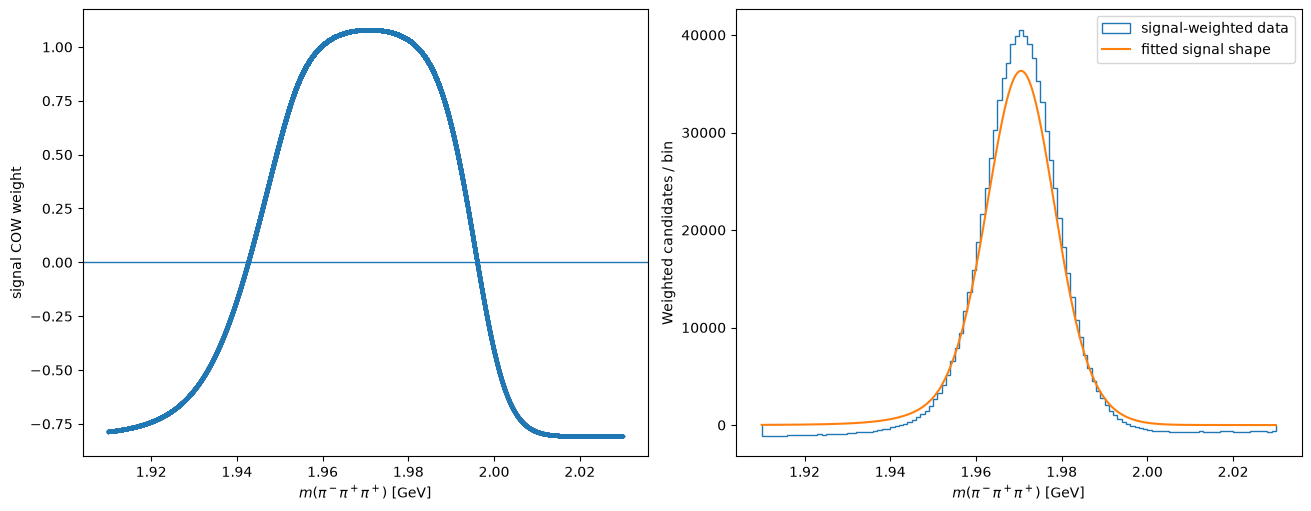

In [9]:
def fitted_signal_mass_pdf(x):
    return signal_mass_pdf(
        x,
        mass_parameters['alpha'],
        mass_parameters['n'],
        mass_parameters['mu_cb'],
        mass_parameters['sigma_cb'],
        mass_parameters['mu_offset'],
        mass_parameters['sigma_ratio'],
        mass_parameters['f_cb'],
    )


def fitted_background_mass_pdf(x):
    return background_mass_pdf(x, mass_parameters['slope'])


fitted_signal_fraction = (
    mass_parameters['nsig']
    / (mass_parameters['nsig'] + mass_parameters['nbkg'])
)


def fitted_total_mass_pdf(x):
    return (
        fitted_signal_fraction * fitted_signal_mass_pdf(x)
        + (1.0 - fitted_signal_fraction) * fitted_background_mass_pdf(x)
    )


cow = Cow(
    MASS_RANGE_GEV,
    fitted_signal_mass_pdf,
    fitted_background_mass_pdf,
    Im=fitted_total_mass_pdf,
    renorm=False,
)

signal_weights = np.asarray(cow(mass), dtype=float)
background_weights = np.asarray(cow(mass, idx=1), dtype=float)

print(f'sum signal COW weights     = {signal_weights.sum():,.1f}')
print(f'fitted signal yield         = {mass_parameters["nsig"]:,.1f}')
print(f'sum background COW weights = {background_weights.sum():,.1f}')
print(f'fitted background yield     = {mass_parameters["nbkg"]:,.1f}')
print(f'min/max signal weight       = {signal_weights.min():.4g}, {signal_weights.max():.4g}')
print(f'negative signal weights     = {np.count_nonzero(signal_weights < 0):,}')
print(f'sum w^2                     = {np.sum(signal_weights**2):,.1f}')
print(
    'N_eff =',
    f'{signal_weights.sum()**2 / np.sum(signal_weights**2):,.1f}',
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].scatter(mass, signal_weights, s=2, alpha=0.25)
axes[0].axhline(0.0, linewidth=1)
axes[0].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='signal COW weight',
)
axes[1].hist(
    mass,
    bins=120,
    range=MASS_RANGE_GEV,
    weights=signal_weights,
    histtype='step',
    label='signal-weighted data',
)
axes[1].plot(
    x_mass,
    bin_width * signal_weights.sum() * fitted_signal_mass_pdf(x_mass),
    label='fitted signal shape',
)
axes[1].set(
    xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]',
    ylabel='Weighted candidates / bin',
)
axes[1].legend()
plt.show()


## 7. Per-event signal probability

With the mass-fit parameters frozen, each candidate gets

$$p_i=\frac{N_s\,P_s(m_i)}{N_s\,P_s(m_i)+N_b\,P_b(m_i)}.$$

Unlike a COW/sWeight, $p_i$ is a probability, always in $[0,1]$. At the maximum of the extended
mass likelihood, $\partial(-\ln\mathcal{L})/\partial N_s=0$ gives $\sum_i p_i=N_s$ exactly, which is
checked below. This identity is also why the Dalitz projections of Section 11 can use the scalar
fraction $\bar p=\sum_i p_i/N$: summed over events, the per-event model
$\sum_i[p_i S+(1-p_i)B]$ is $N[\bar p\,S+(1-\bar p)\,B]$.

sum p_i                  = 770,725.9
fitted signal yield      = 770,725.9
mean p_i                 = 0.8565
fitted signal fraction   = 0.8565
min/max p_i              = 1.304e-06, 0.9717
fraction with p_i > 0.1  = 0.9441
fraction with p_i > 0.5  = 0.9020
fraction with p_i > 0.9  = 0.7763


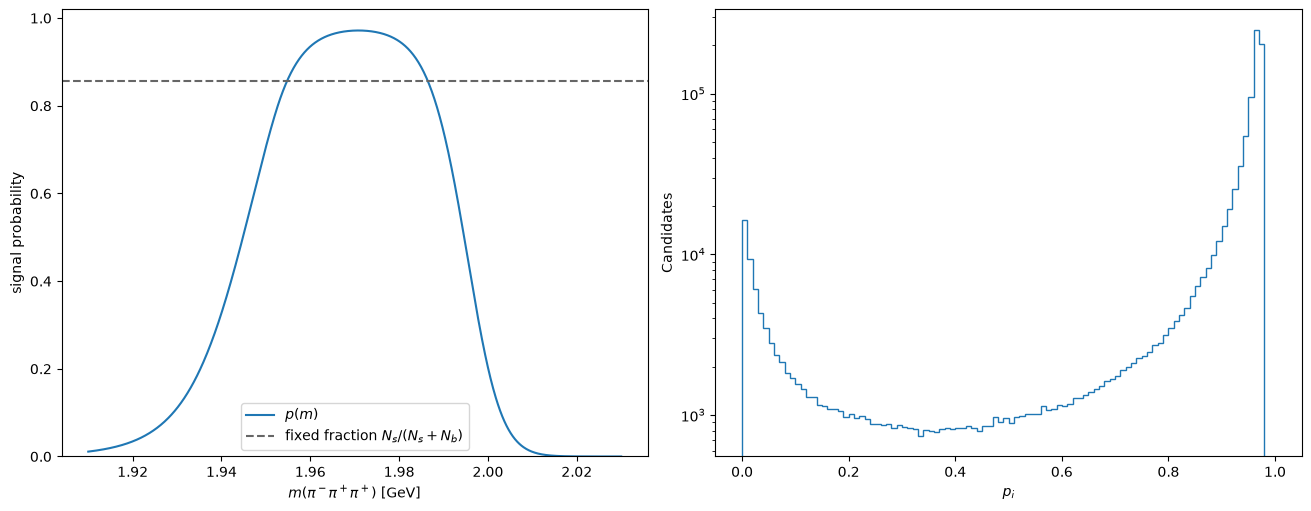

In [10]:
signal_mass_density = mass_parameters['nsig'] * np.asarray(fitted_signal_mass_pdf(mass))
background_mass_density = mass_parameters['nbkg'] * np.asarray(fitted_background_mass_pdf(mass))
signal_probability = signal_mass_density / (signal_mass_density + background_mass_density)

MEAN_SIGNAL_PROBABILITY = float(signal_probability.mean())

print(f'sum p_i                  = {signal_probability.sum():,.1f}')
print(f'fitted signal yield      = {mass_parameters["nsig"]:,.1f}')
print(f'mean p_i                 = {MEAN_SIGNAL_PROBABILITY:.4f}')
print(f'fitted signal fraction   = {fitted_signal_fraction:.4f}')
print(f'min/max p_i              = {signal_probability.min():.4g}, {signal_probability.max():.4g}')
for threshold in (0.1, 0.5, 0.9):
    print(f'fraction with p_i > {threshold:.1f}  = {np.mean(signal_probability > threshold):.4f}')

signal_probability_curve = (
    mass_parameters['nsig'] * np.asarray(signal_curve)
    / (mass_parameters['nsig'] * np.asarray(signal_curve) + mass_parameters['nbkg'] * np.asarray(background_curve))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
axes[0].plot(x_mass, signal_probability_curve, label='$p(m)$')
axes[0].axhline(fitted_signal_fraction, linestyle='--', color='0.4', label='fixed fraction $N_s/(N_s+N_b)$')
axes[0].set(xlabel=r'$m(\pi^-\pi^+\pi^+)$ [GeV]', ylabel='signal probability', ylim=(0.0, 1.02))
axes[0].legend()
axes[1].hist(signal_probability, bins=100, range=(0.0, 1.0), histtype='step')
axes[1].set(xlabel='$p_i$', ylabel='Candidates', yscale='log')
plt.show()

## 8. Background histogram from the COW background weight

Instead of feeding `background_weights` into the Dalitz likelihood event by event, they are used
**once** to fill an ordinary 2D `(s12, s13)` histogram, on the same binning as the efficiency
map loaded above (`efficiency.x_edges`/`efficiency.y_edges`, 300x300 = 90,000 bins) so the two maps
share one grid. This turns the COW background estimate into exactly the same kind of object the
plain `ds_pipipi_lhcb2023_goofit_real_data_fit.ipynb` example loads from a sideband ROOT
histogram — from here on, the notebook runs a completely ordinary, unweighted extended-likelihood
fit with a `BackgroundSpec`.

`background_weights` can be negative (the COW construction has no positivity constraint per
event), so individual histogram bins can come out negative even though their sum
($\approx N_{bkg}$ from the mass fit) is not; `HistogramBackground` requires non-negative bin
values, so negative bins are clipped to zero. This is the same convention already used for
negative event-by-event weights elsewhere in the package (see `docs/discriminants_and_constraints.md`,
"negative weights constraint").

With $N_{bkg}\approx 129\text{k}$ spread over 90,000 bins, the raw piecewise-constant histogram
averages only ~1.4 candidates/bin and is visibly noisy. `HistogramBackground(interpolation='linear')`
bilinearly interpolates between bin centres (`docs/backgrounds_and_vetoes.md`, "Importing
Square-Dalitz histogram densities" documents the same option for the Square-Dalitz variant; it
applies identically to the ordinary `(s12, s13)` histogram used here) to smooth that
piecewise-constant noise. `interpolation='spline'` is deliberately not used, since cubic
interpolation can overshoot below zero between sparse/noisy neighbouring bins (the values are
still clamped to zero downstream, but that clamping would then be doing real work bin to bin
instead of only guarding against the negative-weight clipping above).

background histogram bins            = 90,000
negative bins (clipped to zero)      = 6,991
sum before clipping                  = 129,105.1
sum after clipping                   = 131,479.3
fitted background yield (mass fit)   = 129,105.1


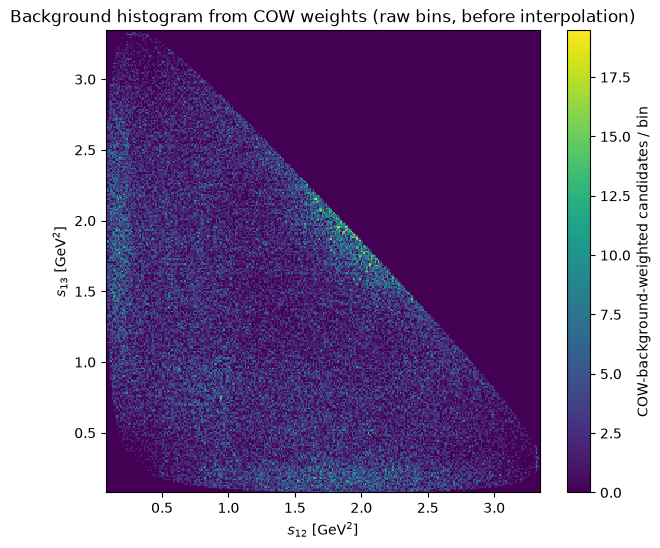

In [11]:
bkg_hist_counts, bkg_x_edges, bkg_y_edges = np.histogram2d(
    np.asarray(data.s12),
    np.asarray(data.s13),
    bins=[np.asarray(efficiency.x_edges), np.asarray(efficiency.y_edges)],
    weights=background_weights,
)

n_negative_bins = int(np.count_nonzero(bkg_hist_counts < 0.0))
print(f'background histogram bins            = {bkg_hist_counts.size:,}')
print(f'negative bins (clipped to zero)      = {n_negative_bins:,}')
print(f'sum before clipping                  = {bkg_hist_counts.sum():,.1f}')

bkg_hist_values = np.clip(bkg_hist_counts, 0.0, None)
print(f'sum after clipping                   = {bkg_hist_values.sum():,.1f}')
print(f'fitted background yield (mass fit)   = {mass_parameters["nbkg"]:,.1f}')

background = HistogramBackground(
    x_edges=jnp.asarray(bkg_x_edges),
    y_edges=jnp.asarray(bkg_y_edges),
    values=jnp.asarray(bkg_hist_values),
    x_variable='s12',
    y_variable='s13',
    interpolation='linear',
)

fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(bkg_x_edges, bkg_y_edges, bkg_hist_values.T, shading='auto')
fig.colorbar(mesh, ax=ax, label='COW-background-weighted candidates / bin')
ax.set(xlabel='$s_{12}$ [GeV$^2$]', ylabel='$s_{13}$ [GeV$^2$]', title='Background histogram from COW weights (raw bins, before interpolation)')
plt.show()


## 9. Pre-fit signal+background toy comparison

The prefit toy is generated with the scalar signal fraction $\bar p$ (equal to the mass-fit
$N_s/(N_s+N_b)$ up to the minimizer tolerance) and the COW background histogram, and compared to the
raw (unweighted) data. Integrated over the mass, this is the same Dalitz distribution the per-event
model predicts for the whole sample.

SIGNAL_FRACTION (mean per-event probability) = 0.8565


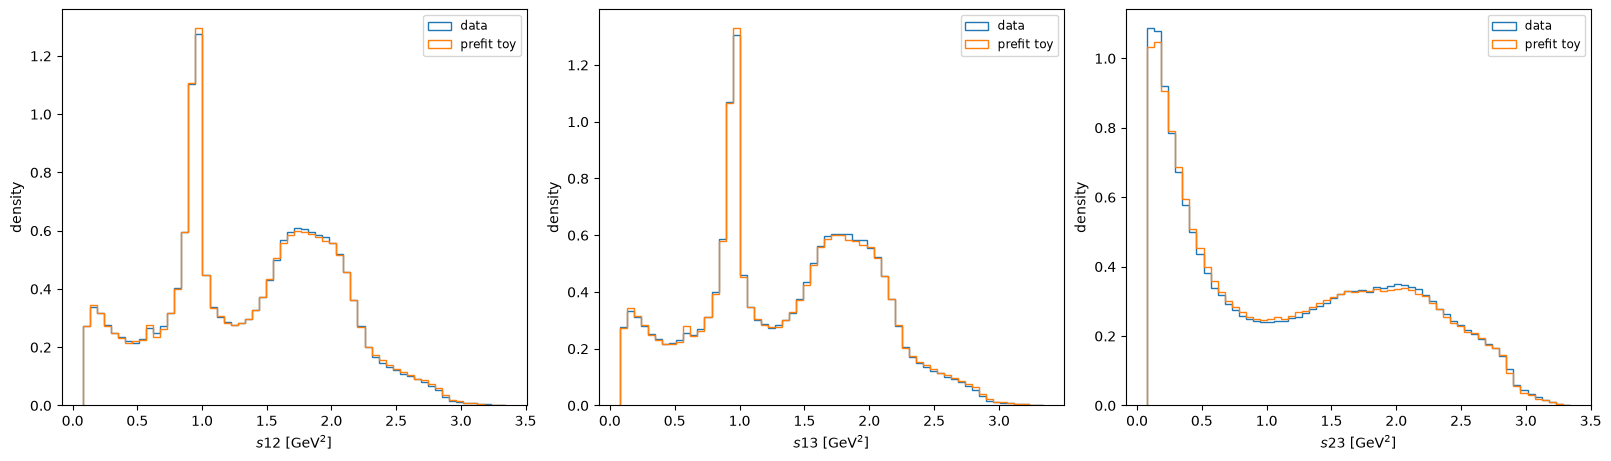

In [12]:
published_start = {p.name: float(p.value) for p in model.parameters if not p.fixed}
SIGNAL_FRACTION = MEAN_SIGNAL_PROBABILITY
print(f'SIGNAL_FRACTION (mean per-event probability) = {SIGNAL_FRACTION:.4f}')

if RUN_PREFIT_TOY_COMPARISON:
    prefit_toy = generate_toy(
        model, data.size, parameters=published_start, efficiency=efficiency,
        signal_fraction=SIGNAL_FRACTION,
        backgrounds=(ToyBackground('cow_background', background),), seed=TOY_SEED,
    )

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    for ax, variable in zip(axes, ('s12', 's13', 's23')):
        observed = np.asarray(getattr(data, variable))
        generated = np.asarray(getattr(prefit_toy, variable))
        edges = np.linspace(min(observed.min(), generated.min()), max(observed.max(), generated.max()), 61)
        ax.hist(observed, bins=edges, histtype='step', label='data', density=True)
        ax.hist(generated, bins=edges, histtype='step', label='prefit toy', density=True)
        ax.set(xlabel='$' + variable + '$ [GeV$^2$]', ylabel='density')
        ax.legend(fontsize='small')
    plt.show()

## 10. Dalitz fit with the per-event signal probability

The `FitSession` below is built with the scalar fraction $\bar p$ only so that it prepares, once,
everything the per-event objective reuses: the amplitude cache (`session.signal_cache`, with the
fixed/floating split of every dynamics parameter), the efficiency on the data
(`session.acceptance_data`), and the normalized background density on the data
(`session.background_categories`). Its own fixed-fraction objective is not minimized here; it is
used afterwards for fit fractions and projections.

The per-event objective is

$$-\ln\mathcal{L}=-\sum_i\ln\big[p_i\,S(x_i)+(1-p_i)\,B(x_i)\big],$$

passed directly to `Minimizer` with the session's own parameter list, so the cache and the
minimizer see the same `Parameter` objects. It is non-extended: the yields were already fixed by
the mass fit, so there is no Poisson term. Errors come from Minuit's curvature of this likelihood
and do not include the mass-fit uncertainty (see the introduction).

`MultiBackgroundNLL` currently requires a scalar `signal_fraction`, which is why the objective is
written out explicitly here.

In [13]:
session = FitSession(
    model, data, efficiency=efficiency, signal_fraction=MEAN_SIGNAL_PROBABILITY,
    backgrounds=(BackgroundSpec('cow_background', background),),
)

# Materialize every parameter-independent array before the minimizer JIT-traces the objective.
_ = session.base_objective
signal_cache = session.signal_cache
acceptance_data = session.acceptance_data
background_density = session.background_categories[0].density
p_signal = jnp.asarray(signal_probability)


def per_event_probability_nll(parameters):
    intensity, normalization = signal_cache.evaluate(parameters)
    signal_density = acceptance_data * intensity / normalization
    density = p_signal * signal_density + (1.0 - p_signal) * background_density
    valid = jnp.isfinite(density) & (density > 0.0)
    nll = -jnp.sum(jnp.log(jnp.where(valid, density, 1.0)))
    return jnp.where(jnp.all(valid), nll, jnp.inf)


per_event_minimizer = Minimizer(
    per_event_probability_nll, session.parameters, tolerance=1e-4, verbose=3
)

if RANDOMIZE_START:
    start = per_event_minimizer.random_start(seed=RANDOMIZE_SEED)
    print('Randomized start (seed=%r):' % RANDOMIZE_SEED, start)
else:
    start = dict(published_start)

print('per-event NLL at start:', float(per_event_probability_nll(start)))

if RUN_FIT:
    result = per_event_minimizer.fit(
        start,
        strategy=1,
        hesse=False,
        simplex=False,
        ncall=250_000,
    )
    print(result)

INFO Jax-PWA normalization: narrow resonance band(s) detected (m12: m0=0.782650 GeV, Gamma=8.490 MeV; m13: m0=0.782650 GeV, Gamma=8.490 MeV); using Square-Dalitz coordinates internally because m12 is diagonal in the conventional m13-m23 plane. Adaptive refinement is applied only along the mass axis m': 1296 m' nodes x 1000 theta' nodes (1,296,000 points).
Randomized start (seed=None): {'S.mag_00': 4.2887098770537975, 'S.mag_01': 4.108801160320133, 'S.mag_02': 3.795180353420049, 'S.mag_03': 4.035483139193046, 'S.mag_04': 4.698672435611585, 'S.mag_05': 4.52110847848587, 'S.mag_06': 5.27222881269498, 'S.mag_07': 5.3099362603623455, 'S.mag_08': 5.994130869819038, 'S.mag_09': 8.281220674600423, 'S.mag_10': 11.733756285878231, 'S.mag_11': 15.903288568563285, 'S.mag_12': 19.801582477064837, 'S.mag_13': 18.922044738519535, 'S.mag_14': 21.075689659929854, 'S.mag_15': 23.349252525267996, 'S.mag_16': 28.206730109800045, 'S.mag_17': 14.878927623167707, 'S.mag_18': 13.479650055388165, 'S.mag_19': 1

## 11. Fit diagnostics

Fit fractions depend only on the fitted amplitude parameters, so `session.print_fit_fractions` is
used directly on the per-event result. The projections use the session's scalar fraction $\bar p$,
which, as shown in Section 7, reproduces the per-event model summed over all candidates.

per-event NLL at fit: 1137898.7477686466
Fit fractions (physical)
component                    fraction [%]        error [%]
pipi_S_qmi                        86.0683           0.1293
rho770                             1.0219           0.0461
omega782                           0.3009           0.0158
rho1450                            4.2562           0.1539
rho1700                            0.5332           0.0606
f2_1270                           13.9303           0.1435
f2p_1525                           0.0468           0.0061
sum                              106.1576

Interference fractions
pair                                                  fraction [%]        error [%]
pipi_S_qmi x rho770                                         0.6606           0.0651
pipi_S_qmi x omega782                                      -0.0776           0.0073
pipi_S_qmi x rho1450                                       -2.3035           0.2538
pipi_S_qmi x rho1700                                       -

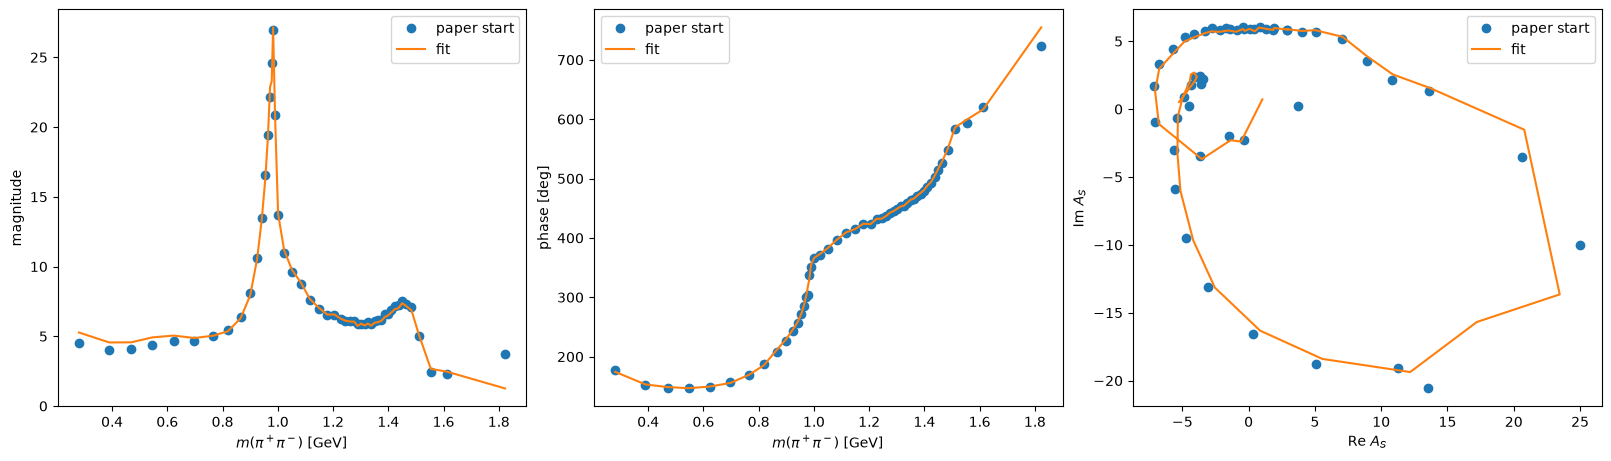

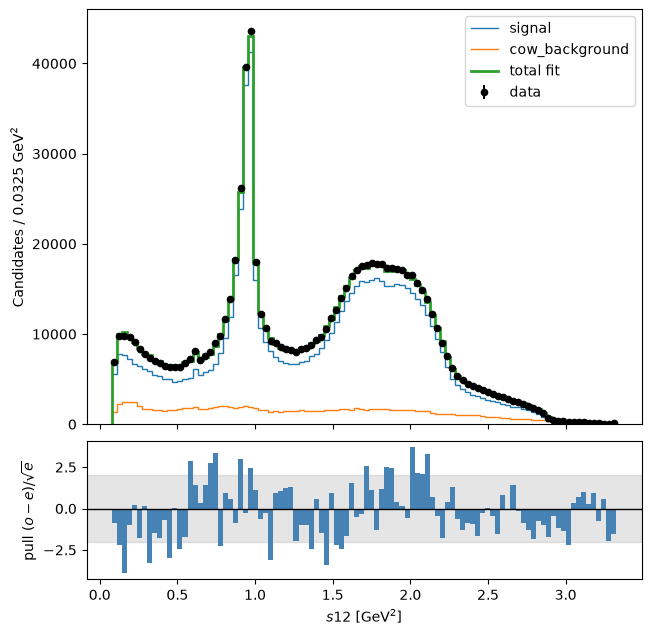

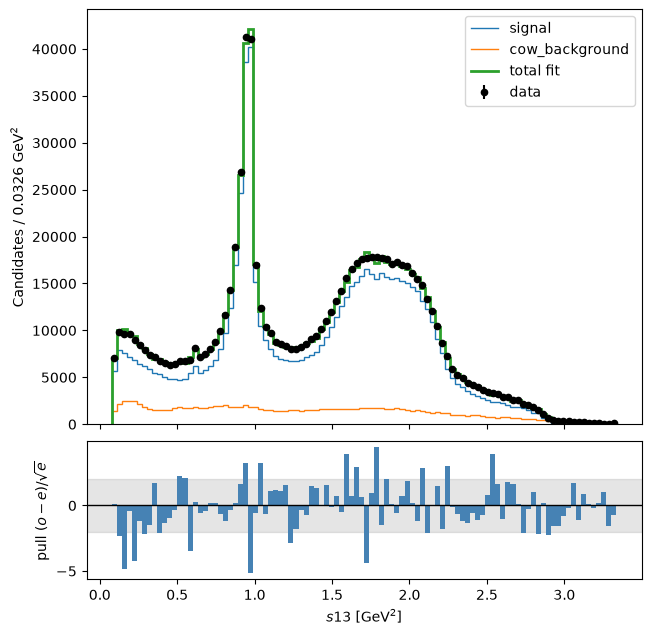

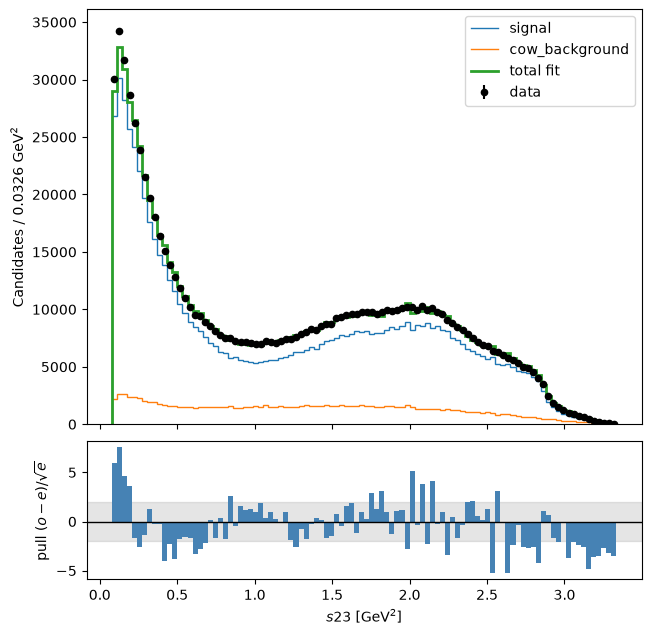

In [14]:
if RUN_FIT:
    values = session.result_values(result)
    print('per-event NLL at fit:', float(per_event_probability_nll(values)))
    session.print_fit_fractions(result, acceptance_weighted=False, include_interference=True, precision=4)

    fit_mag = np.array([values[f'S.mag_{i:02d}'] for i in range(50)])
    fit_phase = np.array([values[f'S.phase_{i:02d}'] for i in range(50)])
    paper_complex = QMI_MAGNITUDE_PAPER * np.exp(1j * QMI_PHASE_RAD_START)
    fit_complex = fit_mag * np.exp(1j * fit_phase)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    axes[0].plot(QMI_KNOTS_GEV, QMI_MAGNITUDE_PAPER, 'o', label='paper start')
    axes[0].plot(QMI_KNOTS_GEV, fit_mag, '-', label='fit')
    axes[0].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='magnitude'); axes[0].legend()
    axes[1].plot(QMI_KNOTS_GEV, np.rad2deg(QMI_PHASE_RAD_START), 'o', label='paper start')
    axes[1].plot(QMI_KNOTS_GEV, np.rad2deg(fit_phase), '-', label='fit')
    axes[1].set(xlabel=r'$m(\pi^+\pi^-)$ [GeV]', ylabel='phase [deg]'); axes[1].legend()
    axes[2].plot(paper_complex.real, paper_complex.imag, 'o', label='paper start')
    axes[2].plot(fit_complex.real, fit_complex.imag, '-', label='fit')
    axes[2].set(xlabel=r'Re $A_S$', ylabel=r'Im $A_S$'); axes[2].legend()
    plt.show()

    for variable in ('s12', 's13', 's23'):
        session.plot_projection(result, variable, bins=100, show_pulls=True)
        plt.show()

## 12. Optional: comparison with the fixed-fraction fit

With `RUN_FIXED_FRACTION_COMPARISON = True`, the same session is also fitted with its ordinary
fixed-fraction likelihood, $f_{sig}\,S+(1-f_{sig})\,B$ with $f_{sig}=\bar p$ for every candidate,
from the same start point, and the fit fractions of both fits are printed side by side.

In [15]:
if RUN_FIT and RUN_FIXED_FRACTION_COMPARISON:
    fixed_fraction_result = session.fit(
        start,
        strategy=1,
        hesse=False,
        simplex=False,
        ncall=250_000,
        tolerance=1e-4,
        verbose=3,
    )
    print('Per-event signal probability fit:')
    session.print_fit_fractions(result, acceptance_weighted=False, precision=4)
    print()
    print('Fixed signal fraction fit:')
    session.print_fit_fractions(fixed_fraction_result, acceptance_weighted=False, precision=4)